In [4]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import re
import anndata as ad


from datetime import datetime
import matplotlib.pyplot as plt

os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [7]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/10_integration_GBM_HIHA/10_subset_macro.h5ad")
checkpoint(f"Loaded: {adata.n_obs:,} cells, {adata.n_vars:,} genes")

[2026-09-24 14:28:01] Loaded: 43,358 cells, 22,586 genes


In [8]:
OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA"

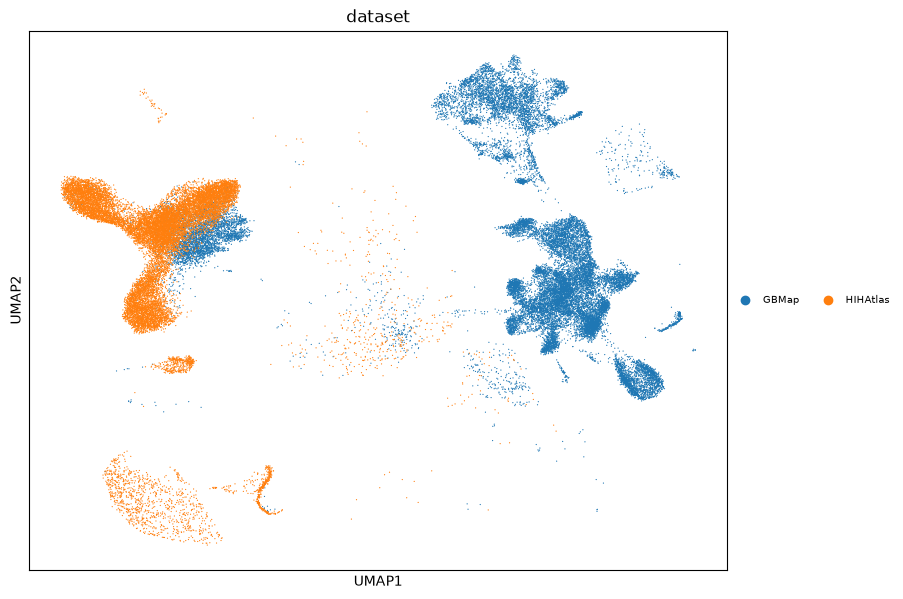

[2026-09-24 11:21:03] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_05_umap_macro_dataset.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["dataset"], ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_05_umap_macro_dataset.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

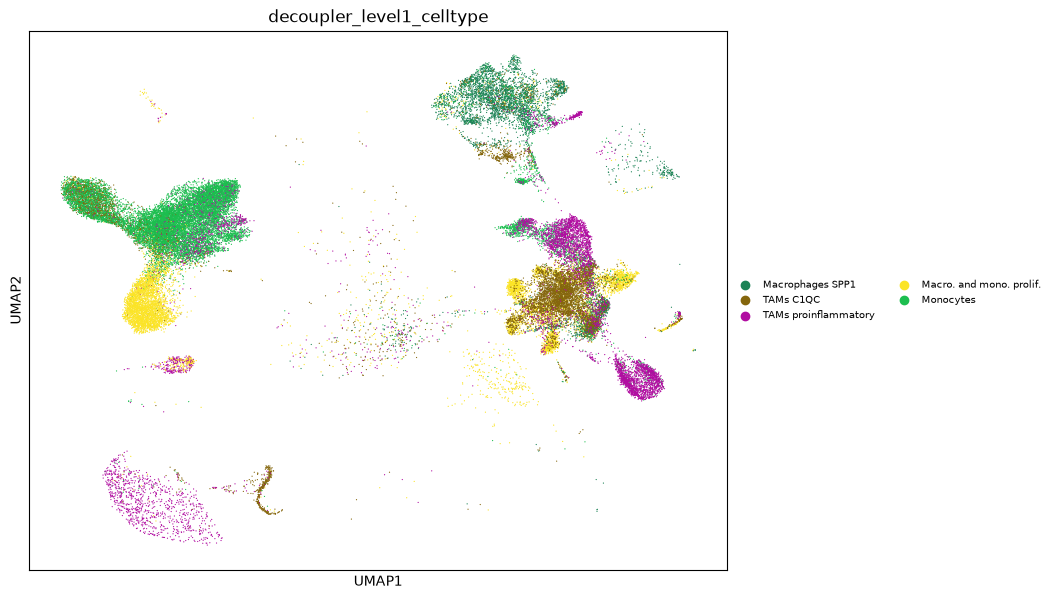

[2026-09-24 11:21:39] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_05_umap_macro_celltype.pdf


In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["decoupler_level1_celltype"], ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_05_umap_macro_celltype.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

### MP scores 

In [3]:
import re
import matplotlib.pyplot as plt

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_04_nmf_macro/mp_scores.csv", index_col=0)


In [9]:
# barcode suffix mismatch -> use intersection instead of direct .loc
common_barcodes = mp_scores.index.intersection(adata.obs_names)
n_missing = adata.n_obs - len(common_barcodes)
checkpoint(f"{len(common_barcodes)} / {adata.n_obs} adata cells matched to mp_scores "
           f"({n_missing} missing)")

[2026-09-24 14:38:41] 43358 / 43358 adata cells matched to mp_scores (0 missing)


[2026-09-24 14:45:21] Plotting UMAPs
[2026-09-24 14:45:21] Plotted MP1_score
[2026-09-24 14:45:21] Plotted MP2_score
[2026-09-24 14:45:21] Plotted MP3_score
[2026-09-24 14:45:21] Plotted MP4_score
[2026-09-24 14:45:21] Plotted MP5_score
[2026-09-24 14:45:21] Plotted MP6_score


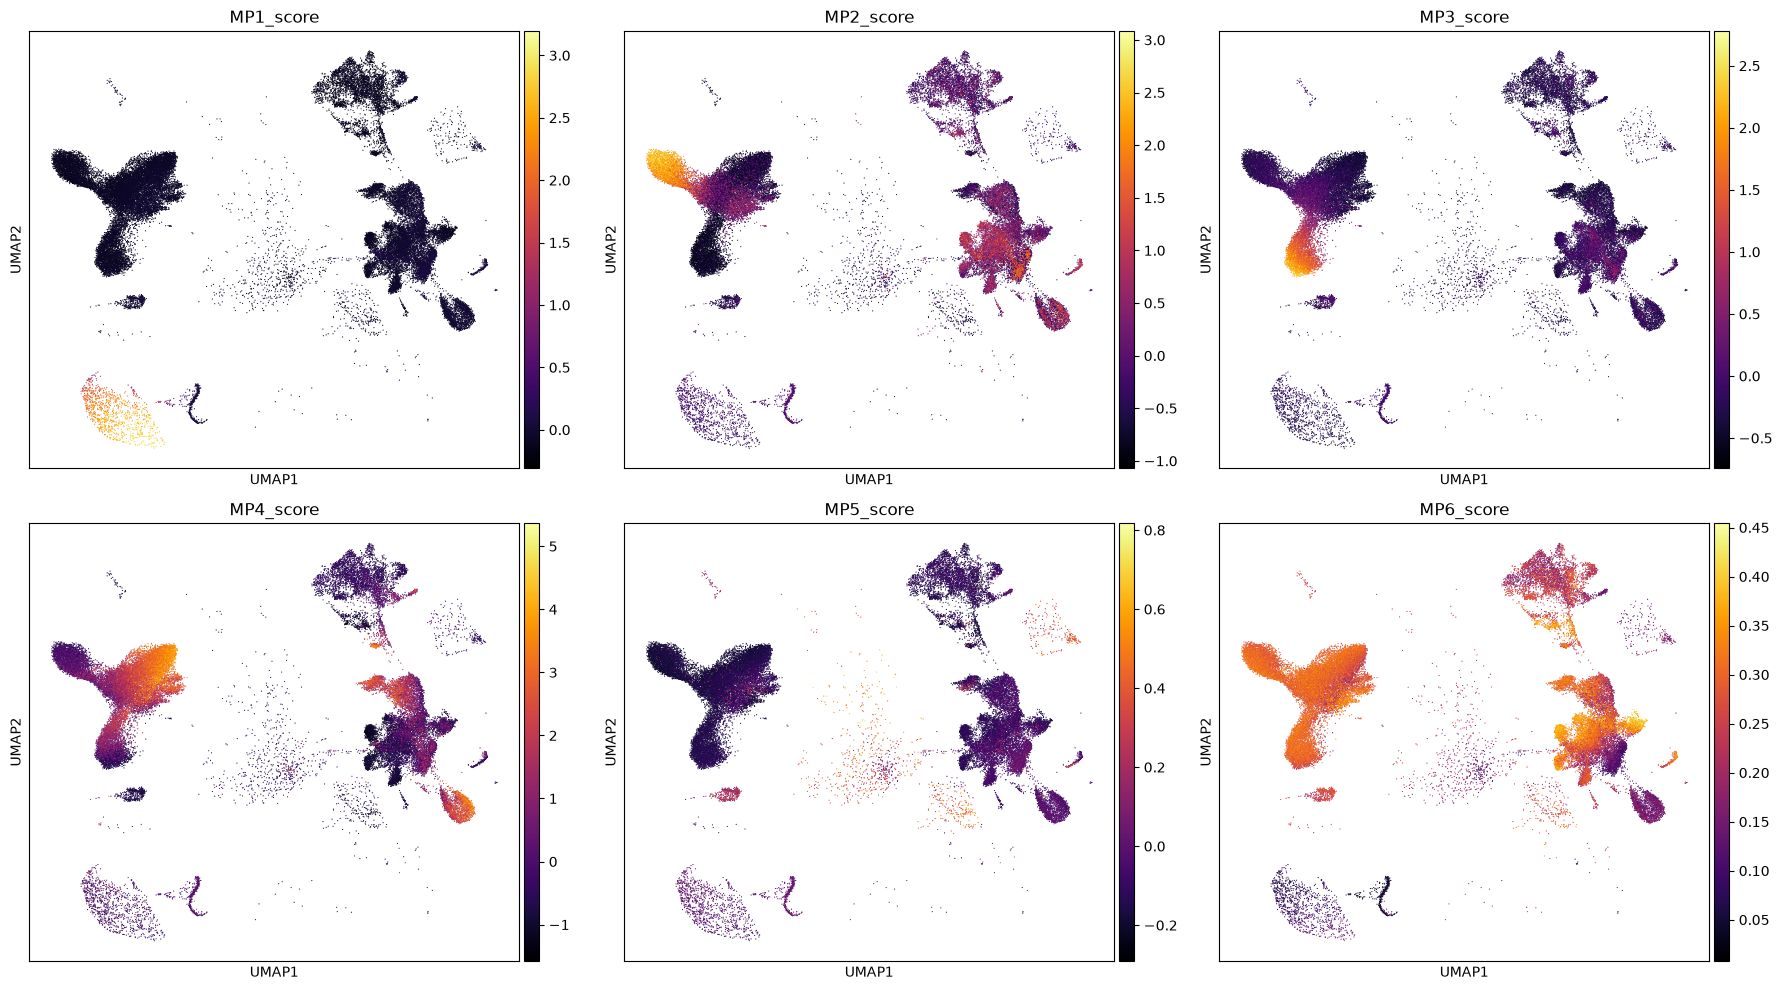

[2026-09-24 14:45:26] PDF saved


In [12]:
# align to adata.obs_names order; unmatched cells become NaN
mp_scores_aligned = mp_scores.reindex(adata.obs_names)

def mp_sort_key(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 0

ALL_MPS = sorted(mp_scores.columns.tolist(), key=mp_sort_key)

for mp in ALL_MPS:
    adata.obs[mp] = mp_scores_aligned[mp].values

checkpoint("Plotting UMAPs")
n_cols = 3
n_rows = -(-len(ALL_MPS) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, mp in enumerate(ALL_MPS):
    if mp in adata.obs.columns:
        sc.pl.umap(adata, color=mp, color_map="inferno", show=False, ax=axes[i], title=mp)
        axes[i].set_rasterized(True)
        checkpoint(f"Plotted {mp}")
    else:
        checkpoint(f"SKIPPED {mp} (not in adata.obs)")

# Hide empty subplots
for j in range(len(ALL_MPS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_05_umap_grid_MP_macro.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint("PDF saved")